In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import pairwise_distances
from tqdm import tqdm
import matplotlib.pyplot as plt

# Load and prepare the data
df = pd.read_csv("ml-latest-small/ratings.csv")
df = df.drop(columns=["timestamp"])
ratings_matrix = df.pivot(index="userId", columns="movieId", values="rating").fillna(0)


In [2]:
def cosine_sim(matrix):
    return cosine_similarity(matrix.fillna(0))

def adjusted_cosine_sim(matrix):
    matrix_centered = matrix.sub(matrix.mean(axis=1), axis=0)
    return cosine_similarity(matrix_centered.fillna(0))

def pearson_sim(matrix):
    matrix = matrix.fillna(0).values
    mean_user_rating = np.true_divide(matrix.sum(1), (matrix != 0).sum(1))
    matrix_centered = matrix - mean_user_rating[:, np.newaxis]
    matrix_centered[np.isnan(matrix_centered)] = 0
    sim = cosine_similarity(matrix_centered)
    return sim

def jaccard_sim(matrix):
    binarized = matrix.fillna(0).astype(bool).astype(int).values
    return 1 - pairwise_distances(binarized, metric="jaccard")


In [3]:
def predict_rating(user_id, item_id, sim_matrix, rating_matrix, k=10, mode='user'):
    if mode == 'user':
        if item_id not in rating_matrix.columns:
            return np.nan
        sims = sim_matrix[user_id - 1]
        ratings = rating_matrix[item_id]
    else:  # item-based
        if user_id not in rating_matrix.index:
            return np.nan
        sims = sim_matrix[rating_matrix.columns.get_loc(item_id)]
        ratings = rating_matrix.loc[user_id]

    # Filter out zero entries
    mask = ratings > 0
    sims = sims[mask]
    ratings = ratings[mask]

    if len(ratings) == 0:
        return np.nan

    # Top-k neighbors
    top_k = np.argsort(sims)[-k:]
    sim_scores = sims[top_k]
    rating_scores = ratings.iloc[top_k]

    if sim_scores.sum() == 0:
        return np.nan

    return np.dot(sim_scores, rating_scores) / np.sum(sim_scores)


In [4]:
def evaluate(rating_matrix, sim_matrix, k, sample_size=500, mode='user'):
    true_ratings = []
    pred_ratings = []

    test_users = np.random.choice(rating_matrix.index, size=sample_size)

    for user_id in tqdm(test_users):
        user_ratings = rating_matrix.loc[user_id]
        rated_items = user_ratings[user_ratings > 0].index
        if len(rated_items) == 0:
            continue
        item_id = np.random.choice(rated_items)
        true_rating = rating_matrix.at[user_id, item_id]

        pred = predict_rating(user_id, item_id, sim_matrix, rating_matrix, k, mode=mode)
        if not np.isnan(pred):
            true_ratings.append(true_rating)
            pred_ratings.append(pred)

    mae = mean_absolute_error(true_ratings, pred_ratings)
    mse = mean_squared_error(true_ratings, pred_ratings)
    rmse = np.sqrt(mse)
    return mae, rmse


In [5]:
similarity_functions = {
    "cosine": cosine_sim,
    "adjusted_cosine": adjusted_cosine_sim,
    "pearson": pearson_sim,
    "jaccard": jaccard_sim,
}

k_values = [10]  # Optional: include [5, 20, 30] if runtime allows
results = []

for mode in ['user', 'item']:
    for name, sim_func in similarity_functions.items():
        print(f"\n{mode.upper()}-BASED: Calculating {name} similarity...")
        sim_matrix = sim_func(ratings_matrix if mode == 'user' else ratings_matrix.T)

        for k in k_values:
            print(f"Evaluating {mode}-based CF with {name} similarity and k = {k}")
            mae, rmse = evaluate(ratings_matrix, sim_matrix, k, mode=mode)
            results.append((mode, name, k, mae, rmse))

# Create DataFrame
results_df = pd.DataFrame(results, columns=["mode", "similarity", "k", "mae", "rmse"])
print(results_df)



USER-BASED: Calculating cosine similarity...
Evaluating user-based CF with cosine similarity and k = 10


100%|██████████| 500/500 [00:00<00:00, 4682.59it/s]


USER-BASED: Calculating adjusted_cosine similarity...


Evaluating user-based CF with adjusted_cosine similarity and k = 10


100%|██████████| 500/500 [00:00<00:00, 4739.22it/s]


...


ITEM-BASED: Calculating jaccard similarity...



c:\Users\victo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


Evaluating item-based CF with jaccard similarity and k = 10


100%|██████████| 500/500 [00:00<00:00, 4089.89it/s]

   mode       similarity   k       mae      rmse
0  user           cosine  10  0.512224  0.684569
1  user  adjusted_cosine  10  0.470447  0.623354
2  user          pearson  10  0.690255  0.897091
3  user          jaccard  10  0.380807  0.522213
4  item           cosine  10  0.522972  0.685689
5  item  adjusted_cosine  10  0.498922  0.666392
6  item          pearson  10  0.650241  0.850520
7  item          jaccard  10  0.497216  0.647661


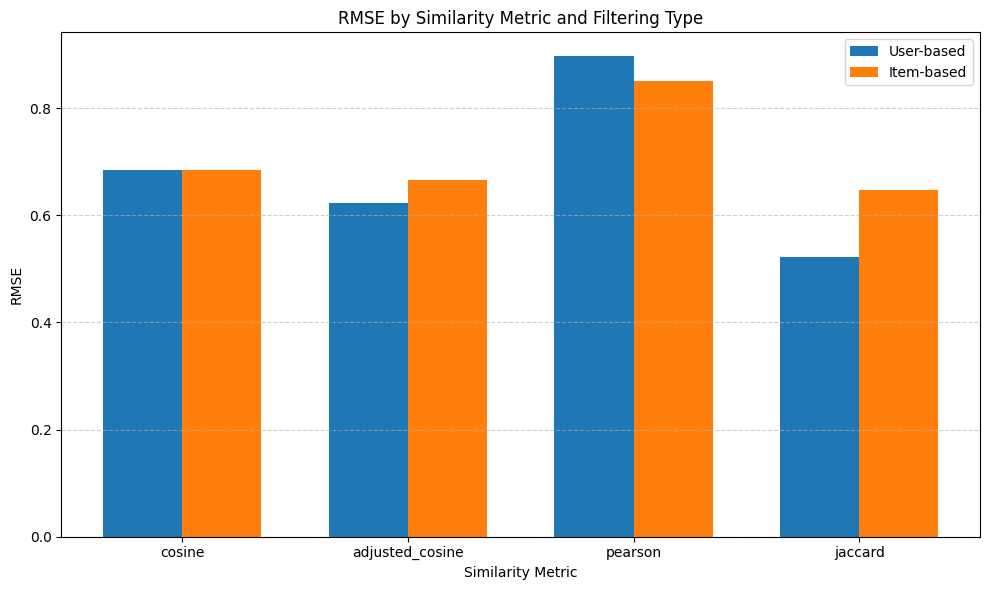

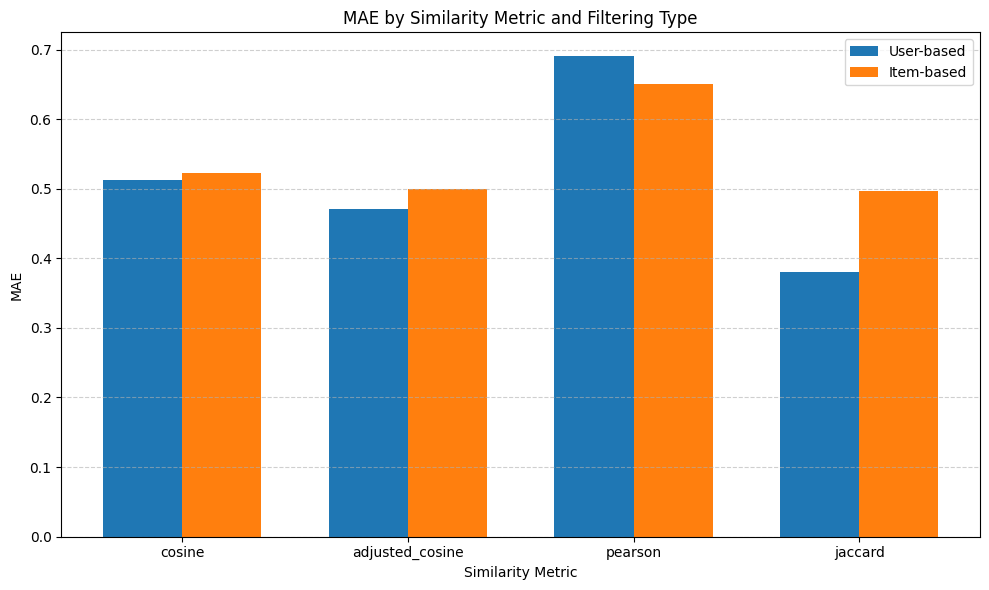

In [6]:
# Separate results for plotting
similarities = results_df["similarity"].unique()
x = np.arange(len(similarities))  # Label locations
width = 0.35  # Width of bars

# Split by mode
user_rmse = results_df[results_df["mode"] == "user"]["rmse"].values
item_rmse = results_df[results_df["mode"] == "item"]["rmse"].values

user_mae = results_df[results_df["mode"] == "user"]["mae"].values
item_mae = results_df[results_df["mode"] == "item"]["mae"].values

# RMSE Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, user_rmse, width, label='User-based')
plt.bar(x + width/2, item_rmse, width, label='Item-based')
plt.ylabel('RMSE')
plt.xlabel('Similarity Metric')
plt.title('RMSE by Similarity Metric and Filtering Type')
plt.xticks(x, similarities)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# MAE Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, user_mae, width, label='User-based')
plt.bar(x + width/2, item_mae, width, label='Item-based')
plt.ylabel('MAE')
plt.xlabel('Similarity Metric')
plt.title('MAE by Similarity Metric and Filtering Type')
plt.xticks(x, similarities)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()